In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(10)

lojas = {
    "Loja Centro": "Centro",
    "Loja Norte": "Norte",
    "Loja Sul": "Sul"
}

produtos = {
    "Camiseta": ("Roupas", 49.90),
    "Calça": ("Roupas", 119.90),
    "Tênis": ("Calçados", 199.90),
    "Sandália": ("Calçados", 79.90),
    "Mochila": ("Acessórios", 89.90)
}

vendas = []

for _ in range(120):
    loja = np.random.choice(list(lojas))
    produto = np.random.choice(list(produtos))
    categoria, preco = produtos[produto]

    vendas.append({
        "data": pd.Timestamp("2026-01-01") + pd.Timedelta(days=int(np.random.randint(0, 240))),
        "loja": loja,
        "regiao": lojas[loja],
        "produto": produto,
        "categoria": categoria,
        "quantidade": int(np.random.randint(1, 8)),
        "preco_unitario": preco
    })

pd.DataFrame(vendas).to_csv("vendas.csv", index=False)

In [5]:
path = r"D:\Python\analise_dados\apostila\vendas.csv"

In [6]:
df = pd.read_csv(path, sep=',', encoding='utf8', decimal=',')

In [7]:
df

,data,loja,regiao,produto,categoria,quantidade,preco_unitario
0,2026-01-16,Loja Norte,Norte,Mochila,Acessórios,1,89.9
1,2026-06-06,Loja Norte,Norte,Sandália,Calçados,2,79.9
2,2026-06-07,Loja Norte,Norte,Camiseta,Roupas,2,49.9
3,2026-03-15,Loja Sul,Sul,Camiseta,Roupas,1,49.9
4,2026-06-14,Loja Sul,Sul,Camiseta,Roupas,4,49.9
...,...,...,...,...,...,...,...
115,2026-02-04,Loja Norte,Norte,Mochila,Acessórios,4,89.9
116,2026-08-02,Loja Sul,Sul,Tênis,Calçados,7,199.9
117,2026-06-08,Loja Centro,Centro,Mochila,Acessórios,2,89.9
118,2026-03-03,Loja Sul,Sul,Tênis,Calçados,2,199.9


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   data            120 non-null    str  
 1   loja            120 non-null    str  
 2   regiao          120 non-null    str  
 3   produto         120 non-null    str  
 4   categoria       120 non-null    str  
 5   quantidade      120 non-null    int64
 6   preco_unitario  120 non-null    str  
dtypes: int64(1), str(6)
memory usage: 6.7 KB


In [9]:
df['quantidade'] = df['quantidade'].astype(int)
df['preco_unitario'] = df['preco_unitario'].astype(float)
df["data"] = pd.to_datetime(df["data"])

df["mes"] = df["data"].dt.month
df["mes_ano"] = df["data"].dt.to_period("M")

In [10]:
df['faturamento'] = df['quantidade'] * df['preco_unitario']

In [11]:
df.describe()

,data,quantidade,preco_unitario,mes,faturamento
count,120,120.000000,120.00000,120.000000,120.000000
mean,2026-05-03 07:36:00,3.491667,108.40000,4.583333,365.734167
min,2026-01-01 00:00:00,1.000000,49.90000,1.000000,49.900000
25%,2026-02-28 12:00:00,2.000000,49.90000,2.750000,159.800000
50%,2026-05-14 12:00:00,3.000000,89.90000,5.000000,259.600000
75%,2026-06-29 06:00:00,5.000000,119.90000,6.000000,479.450000
max,2026-08-28 00:00:00,7.000000,199.90000,8.000000,1399.300000
std,NaN,2.045679,54.75154,2.413489,295.054929


In [12]:
df

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,mes,mes_ano,faturamento
0,2026-01-16,Loja Norte,Norte,Mochila,Acessórios,1,89.9,1,2026-01,89.9
1,2026-06-06,Loja Norte,Norte,Sandália,Calçados,2,79.9,6,2026-06,159.8
2,2026-06-07,Loja Norte,Norte,Camiseta,Roupas,2,49.9,6,2026-06,99.8
3,2026-03-15,Loja Sul,Sul,Camiseta,Roupas,1,49.9,3,2026-03,49.9
4,2026-06-14,Loja Sul,Sul,Camiseta,Roupas,4,49.9,6,2026-06,199.6
...,...,...,...,...,...,...,...,...,...,...
115,2026-02-04,Loja Norte,Norte,Mochila,Acessórios,4,89.9,2,2026-02,359.6
116,2026-08-02,Loja Sul,Sul,Tênis,Calçados,7,199.9,8,2026-08,1399.3
117,2026-06-08,Loja Centro,Centro,Mochila,Acessórios,2,89.9,6,2026-06,179.8
118,2026-03-03,Loja Sul,Sul,Tênis,Calçados,2,199.9,3,2026-03,399.8


In [13]:
faturamento_loja = df.groupby("loja")['faturamento'].sum().sort_values(ascending=False)

In [14]:
print("\nFaturamento por loja:")
display(faturamento_loja)


Faturamento por loja:


loja
Loja Sul       15715.1
Loja Norte     15484.5
Loja Centro    12688.5
Name: faturamento, dtype: float64

In [15]:
ticket_medio = df.groupby("loja")["faturamento"].mean().sort_values(ascending=False)

In [16]:
print("\nTicket médio por loja:")
display(ticket_medio)


Ticket médio por loja:


loja
Loja Centro    409.306452
Loja Norte     351.920455
Loja Sul       349.224444
Name: faturamento, dtype: float64

In [17]:
quantidade_produtos = df.groupby("produto")["quantidade"].sum().nlargest(5)

In [18]:
print("\nQuantidade Produtos:")
display(quantidade_produtos)


Quantidade Produtos:


produto
Camiseta    113
Mochila      84
Tênis        83
Calça        75
Sandália     64
Name: quantidade, dtype: int64

In [27]:
faturamento_mensal = df.groupby("mes_ano")["faturamento"].sum().sort_index()
faturamento_mensal

mes_ano
2026-01    5454.4
2026-02    4277.3
2026-03    5075.5
2026-04    6643.6
2026-05    3945.3
2026-06    7732.1
2026-07    3456.8
2026-08    7303.1
Freq: M, Name: faturamento, dtype: float64

In [19]:
mes_maior_faturamento = df.groupby("mes_ano")["faturamento"].sum().sort_values(ascending=False)
mes_maior_faturamento

mes_ano
2026-06    7732.1
2026-08    7303.1
2026-04    6643.6
2026-01    5454.4
2026-03    5075.5
2026-02    4277.3
2026-05    3945.3
2026-07    3456.8
Freq: M, Name: faturamento, dtype: float64

In [20]:
print("Mês com maior faturamento:",
      mes_maior_faturamento.idxmax().strftime("%m/%Y"))

Mês com maior faturamento: 06/2026


In [21]:
mes_menor_faturamento = df.groupby("mes_ano")["faturamento"].sum().sort_values(ascending=True)
mes_menor_faturamento

mes_ano
2026-07    3456.8
2026-05    3945.3
2026-02    4277.3
2026-03    5075.5
2026-01    5454.4
2026-04    6643.6
2026-08    7303.1
2026-06    7732.1
Freq: M, Name: faturamento, dtype: float64

In [22]:
print("Mês com menor faturamento:",
      mes_menor_faturamento.idxmin().strftime("%m/%Y"))

Mês com menor faturamento: 07/2026


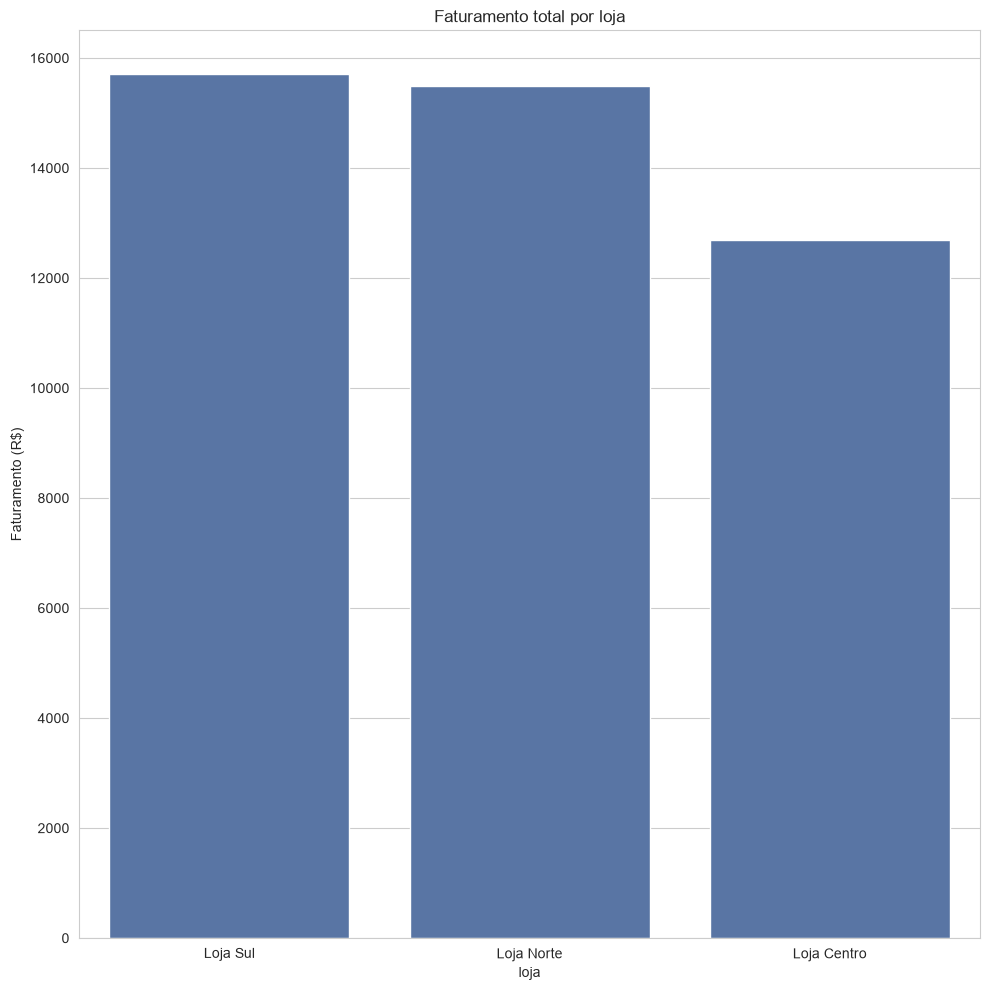

In [43]:
sns.set_style("whitegrid")
sns.set_palette("deep")

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    x=faturamento_loja.index, 
    y=faturamento_loja.values,
    ax=ax
    )
ax.set_title("Faturamento total por loja")
ax.set_xlabel("loja")
ax.set_ylabel("Faturamento (R$)")
fig.tight_layout()

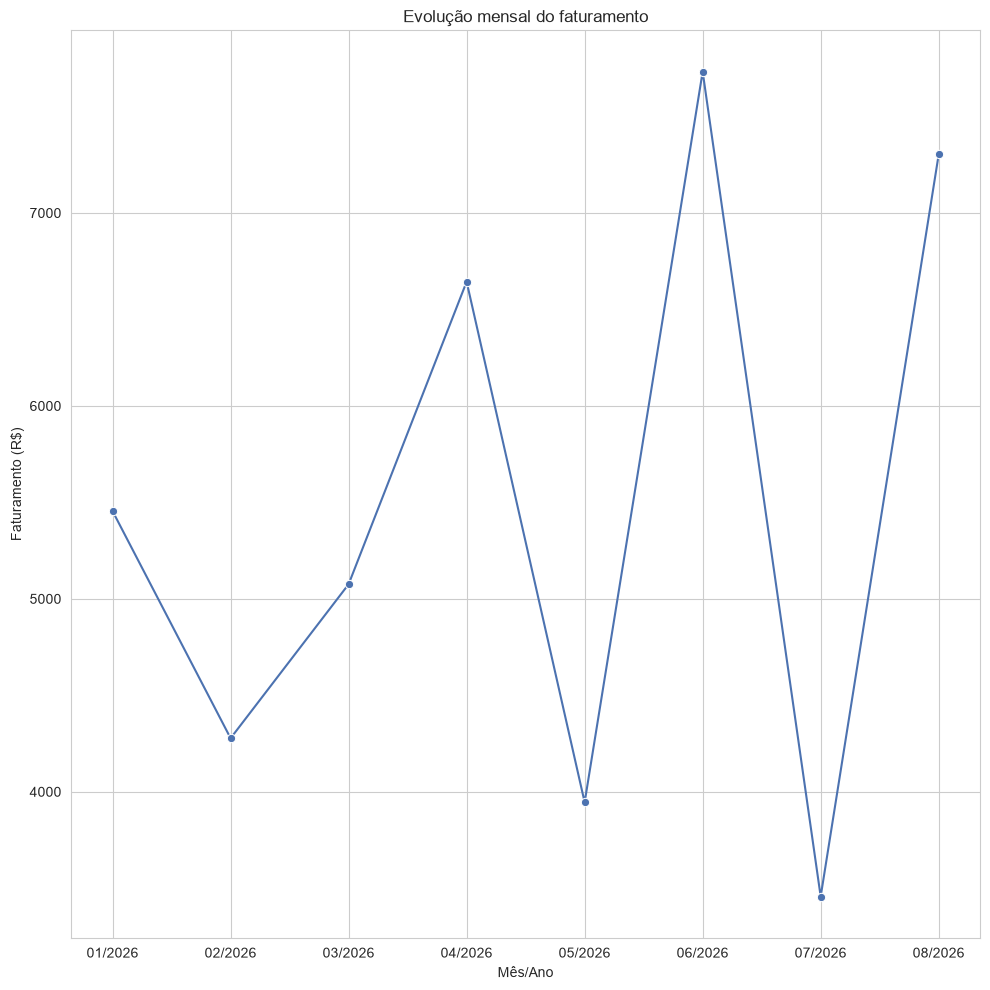

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))
meses =  [mes.strftime("%m/%Y") for mes in faturamento_mensal.index]
sns.lineplot(
    x=meses,
    y=faturamento_mensal.values,
    marker="o"
)
ax.set_title("Evolução mensal do faturamento")
ax.set_xlabel("Mês/Ano")
ax.set_ylabel("Faturamento (R$)")
fig.tight_layout()

In [31]:
df

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,mes,mes_ano,faturamento
0,2026-01-16,Loja Norte,Norte,Mochila,Acessórios,1,89.9,1,2026-01,89.9
1,2026-06-06,Loja Norte,Norte,Sandália,Calçados,2,79.9,6,2026-06,159.8
2,2026-06-07,Loja Norte,Norte,Camiseta,Roupas,2,49.9,6,2026-06,99.8
3,2026-03-15,Loja Sul,Sul,Camiseta,Roupas,1,49.9,3,2026-03,49.9
4,2026-06-14,Loja Sul,Sul,Camiseta,Roupas,4,49.9,6,2026-06,199.6
...,...,...,...,...,...,...,...,...,...,...
115,2026-02-04,Loja Norte,Norte,Mochila,Acessórios,4,89.9,2,2026-02,359.6
116,2026-08-02,Loja Sul,Sul,Tênis,Calçados,7,199.9,8,2026-08,1399.3
117,2026-06-08,Loja Centro,Centro,Mochila,Acessórios,2,89.9,6,2026-06,179.8
118,2026-03-03,Loja Sul,Sul,Tênis,Calçados,2,199.9,3,2026-03,399.8


In [32]:
faturamento_por_regiao = df.groupby("regiao")["faturamento"].sum().sort_values(ascending=False)
faturamento_por_regiao

regiao
Sul       15715.1
Norte     15484.5
Centro    12688.5
Name: faturamento, dtype: float64

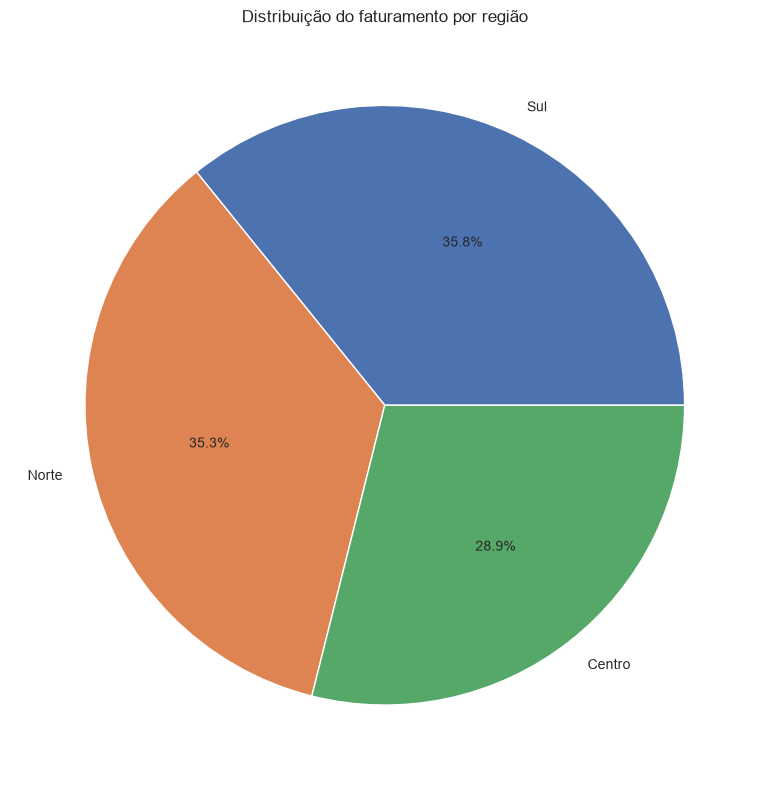

In [47]:
fig, ax = plt.subplots(figsize=(8,8))
plt.pie(
    faturamento_por_regiao.values,
    labels=faturamento_por_regiao.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("deep", len(faturamento_por_regiao))
)
ax.set_title("Distribuição do faturamento por região")
fig.tight_layout()


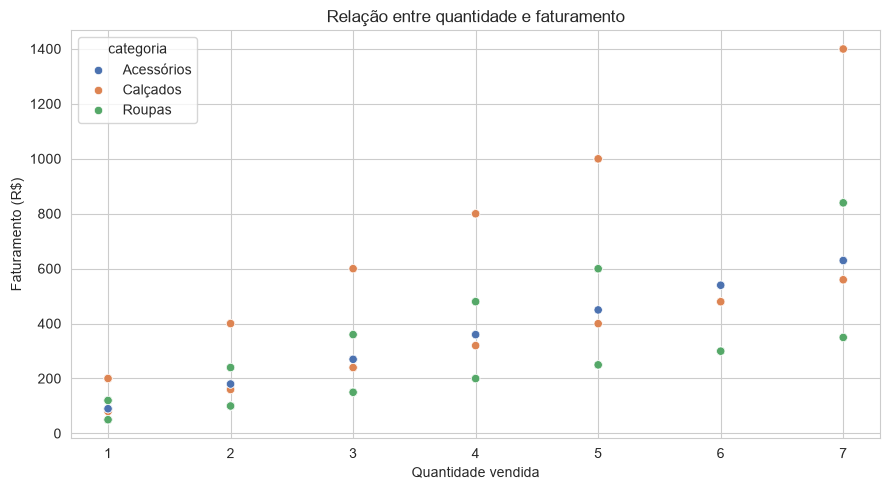

In [36]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="quantidade", y="faturamento", hue="categoria")
plt.title("Relação entre quantidade e faturamento")
plt.xlabel("Quantidade vendida")
plt.ylabel("Faturamento (R$)")
plt.tight_layout()
plt.show()

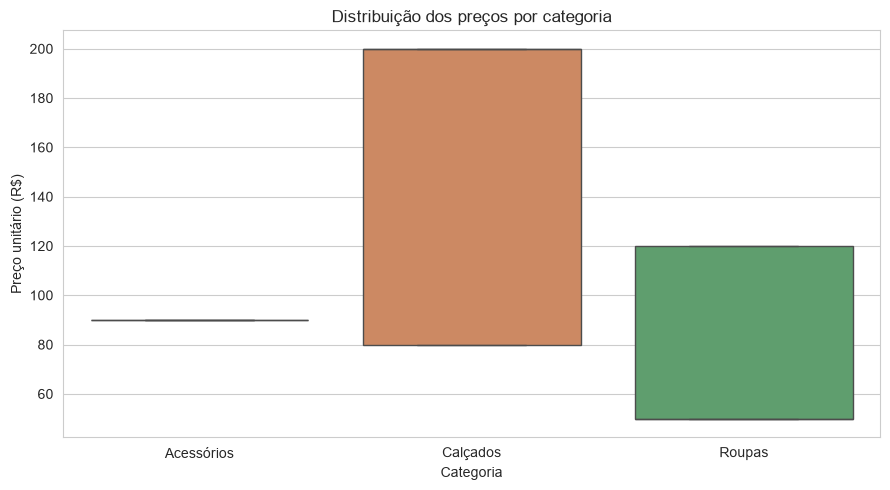

In [38]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="categoria", y="preco_unitario", hue="categoria", legend=False)
plt.title("Distribuição dos preços por categoria")
plt.xlabel("Categoria")
plt.ylabel("Preço unitário (R$)")
plt.tight_layout()
plt.show()

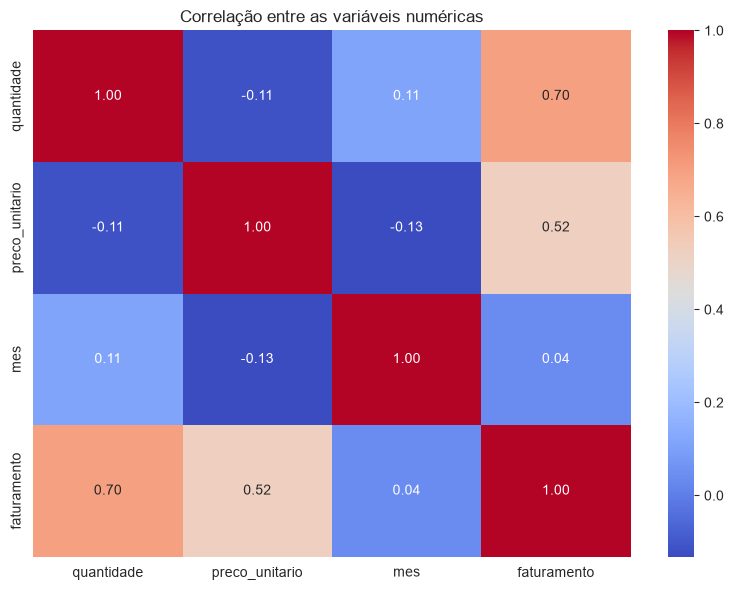

In [45]:
# Seleciona apenas as colunas numéricas e calcula a correlação
correlacao = df.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=ax
)

ax.set_title("Correlação entre as variáveis numéricas")
fig.tight_layout()
plt.show()

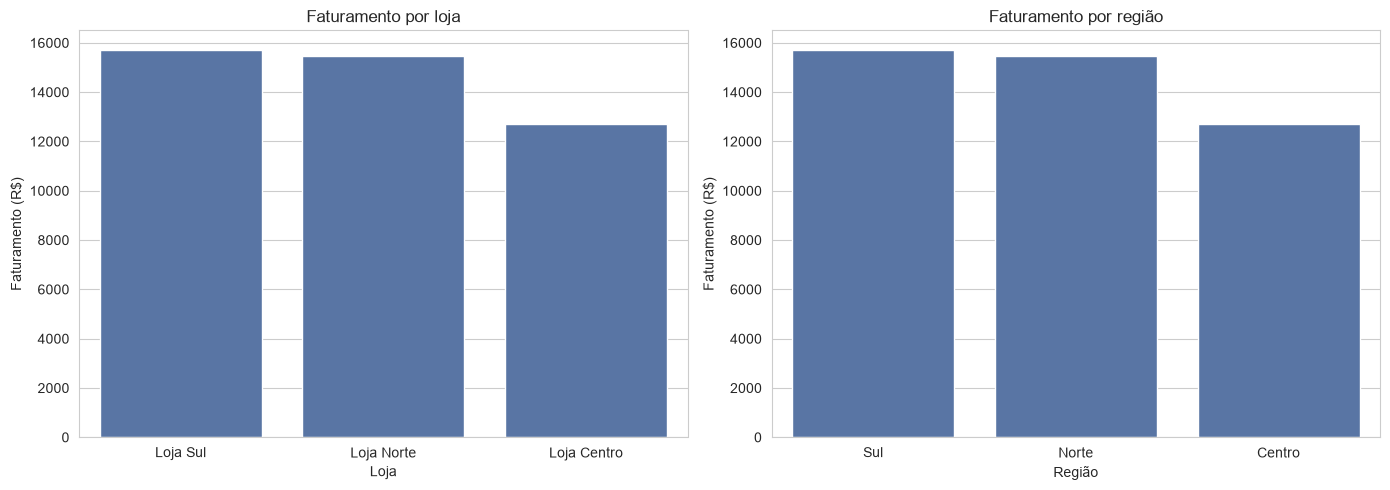

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=faturamento_loja.index,
    y=faturamento_loja.values,
    ax=axes[0]
)
axes[0].set_title("Faturamento por loja")
axes[0].set_xlabel("Loja")
axes[0].set_ylabel("Faturamento (R$)")

sns.barplot(
    x=faturamento_por_regiao.index,
    y=faturamento_por_regiao.values,
    ax=axes[1]
)
axes[1].set_title("Faturamento por região")
axes[1].set_xlabel("Região")
axes[1].set_ylabel("Faturamento (R$)")

fig.tight_layout()
plt.show()

In [50]:
resumo = df.groupby(["loja", "regiao"], as_index=False).agg(
    numero_vendas=("faturamento", "size"),
    quantidade_vendida=("quantidade", "sum"),
    faturamento_total=("faturamento", "sum"),
    ticket_medio=("faturamento", "mean")
)

resumo.to_csv("resumo_analitico.csv", index=False)
display(resumo)

,loja,regiao,numero_vendas,quantidade_vendida,faturamento_total,ticket_medio
0,Loja Centro,Centro,31,115,12688.5,409.306452
1,Loja Norte,Norte,44,155,15484.5,351.920455
2,Loja Sul,Sul,45,149,15715.1,349.224444
